# Entrenamiento de los modelos con datos NHANES

Este entrenamiento es realizado con los datos recabados por National Health and Nutrition Examination Survey (NHANES) y que fueron agrupados en un solo archivo csv con el código de archivo Data_cleaning_and_grouping.

El objetivo es generar 3 modelos (Árbol de decisión, SVM, Red neuronal MLPClassifier) que predigan las enfermedades, se utilizan  3 condiciones para cada modelo:
- Sin SMOTE
- Con SMOTE
- Con ADASYN



Importamos los datos

Definimos los parámetros encontrados para cada enfermedad:

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import f1_score, roc_auc_score
from imblearn.over_sampling import SMOTE, ADASYN

In [2]:
data_NHANES_2017_2020 = "data_test/NHANES_2017_2020_reetiquetado.csv"

In [3]:
# Mapeo de los nombre de las columnas
COL = {
    "platelets":  "Platelets",
    "wbc":        "White Blood Cells",
    "rbc":        "Red Blood Cells",
    "hematocrit": "Hematocrit",
    "mcv":        "Mean Corpuscular Volume",
    "mch":        "Mean Corpuscular Hemoglobin",
    "mchc":       "Mean Corpuscular Hemoglobin Concentration",
    "hdl":        "HDL Cholesterol",
    "alt":        "ALT",
    "heart_rate": "Heart Rate",
}

TARGET_COLUMN = "condition"

In [4]:
CLINICAL_THRESHOLDS = {
    "thrombocytopenia": {
        "platelets": {"max": 150.0},    
        "reference": "ASH / NHANES reference range"
    },

    "thalassemia": {
        "mcv": {"max": 80.0},               # MCV < 80 fl
        "mch": {"max": 27.0},               # MCH < 27 pg  (ambos deben cumplirse)
        "reference": "Harrison's Principles of Internal Medicine 2022"
    },

    "anemia": {
        "mchc": {"max": 32.0},
        "reference": "WHO 2011 — proxy via MCHC < 32 g/dL (Hb no disponible)"
    },

    "healthy": {
        "platelets": {"min": 150.0, "max": 400.0},  # 150k–400k /uL
        "mchc":      {"min": 32.0,      "max": 36.0},        # g/dL normal
        "mcv":       {"min": 80.0,      "max": 100.0},       # fl normal
        "mch":       {"min": 27.0,      "max": 33.0},        # pg normal
        "reference": "NHANES reference ranges"
    },
}

In [5]:
# Variables optimas
OPTIMAL_FEATURES = list(COL.values())

# Criterio de exclusión
# Siver para eliminar datos atipicos que puedan afectar el entrenamiento
EXCLUSION_CRITERIA = {
    "max_platelets":     2_000.0,
    "min_platelets":     1.0,
    "max_mcv":           150.0,
    "min_mcv":           50.0,
    "max_mch":           50.0,
    "missing_threshold": 0.40,
}

def apply_exclusion_criteria(df: pd.DataFrame) -> pd.DataFrame:
    n_initial = len(df)
    log = []

    checks = [
        (COL["platelets"], "max_platelets", "<="),
        (COL["platelets"], "min_platelets", ">="),
        (COL["mcv"],       "max_mcv",       "<="),
        (COL["mcv"],       "min_mcv",       ">="),
        (COL["mch"],       "max_mch",       "<="),
    ]
    for col, key, op in checks:
        if col in df.columns:
            n_before = len(df)
            mask = df[col].isna() | (df[col] <= EXCLUSION_CRITERIA[key] if op == "<=" else df[col] >= EXCLUSION_CRITERIA[key])
            df = df[mask]
            removed = n_before - len(df)
            if removed > 0:
                log.append(f"  Valores imposibles en '{col}': {removed} filas eliminadas")

    feat_cols    = [c for c in OPTIMAL_FEATURES if c in df.columns]
    missing_frac = df[feat_cols].isna().mean(axis=1)
    n_before     = len(df)
    df = df[missing_frac <= EXCLUSION_CRITERIA["missing_threshold"]]
    log.append(f"  Filas con >40% NaN: {n_before - len(df)} eliminadas")
    return df.reset_index(drop=True)

In [6]:
# Etiquetaco con las parametros establecidos
def label_condition(row: pd.Series) -> str:
    thr       = CLINICAL_THRESHOLDS
    platelets = row.get(COL["platelets"], np.nan)
    mcv       = row.get(COL["mcv"],       np.nan)
    mch       = row.get(COL["mch"],       np.nan)
    mchc      = row.get(COL["mchc"],      np.nan)

    # Trombocitopenia
    if not np.isnan(platelets) and platelets < thr["thrombocytopenia"]["platelets"]["max"]:
        return "thrombocytopenia"

    # Talasemia (MCV Y MCH deben estar bajos)
    mcv_low = not np.isnan(mcv) and mcv < thr["thalassemia"]["mcv"]["max"]
    mch_low = not np.isnan(mch) and mch < thr["thalassemia"]["mch"]["max"]
    if mcv_low and mch_low:
        return "thalassemia"

    # Anemia (proxy MCHC)
    if not np.isnan(mchc) and mchc < thr["anemia"]["mchc"]["max"]:
        return "anemia"

    # Sano (todos los indicadores dentro del rango normal)
    plt_ok  = not np.isnan(platelets) and thr["healthy"]["platelets"]["min"] <= platelets <= thr["healthy"]["platelets"]["max"]
    mchc_ok = not np.isnan(mchc)      and thr["healthy"]["mchc"]["min"]      <= mchc      <= thr["healthy"]["mchc"]["max"]
    mcv_ok  = not np.isnan(mcv)       and thr["healthy"]["mcv"]["min"]       <= mcv       <= thr["healthy"]["mcv"]["max"]
    mch_ok  = not np.isnan(mch)       and thr["healthy"]["mch"]["min"]       <= mch       <= thr["healthy"]["mch"]["max"]
    if plt_ok and mchc_ok and mcv_ok and mch_ok:
        return "healthy"

    # Borderline: no cumple criterio de enfermedad ni de sano estricto
    return "borderline"

In [7]:
# Carga de datos
def load_and_prepare(path: str):
    df = pd.read_csv(path)
    print(f"[Carga] Dataset original: {df.shape}")

    df = apply_exclusion_criteria(df)

    if TARGET_COLUMN not in df.columns:
        
        df[TARGET_COLUMN] = df.apply(label_condition, axis=1)
    else:
        print(f"\n[Etiquetado] Columna '{TARGET_COLUMN}' ya existe — usando etiquetas del CSV")


    available = [f for f in OPTIMAL_FEATURES if f in df.columns]
    missing   = set(OPTIMAL_FEATURES) - set(available)
    if missing:
        print(f"\n[Advertencia] No encontradas en CSV: {missing}")

    X  = df[available].fillna(df[available].median(numeric_only=True)).values
    le = LabelEncoder()
    y  = le.fit_transform(df[TARGET_COLUMN])
    

    # Guardamos el etiquetado 
    df.to_csv("data_test/NHANES_2017_2020_labeled_diseases.csv", index=False)
    return X, y, le.classes_

In [8]:
# Repote de estrategia para el balaceo de datos
MODELS = {
    "DecisionTree": DecisionTreeClassifier(
        max_depth=10, min_samples_split=10,
        class_weight="balanced", random_state=42
    ),
    "SVM": SVC(
        C=1.0, kernel="rbf", gamma="scale",
        probability=True, class_weight="balanced", random_state=42
    ),
    "MLP": MLPClassifier(
        hidden_layer_sizes=(128, 64), activation="relu", solver="adam",
        max_iter=500, early_stopping=True, validation_fraction=0.1, random_state=42
    ),
}

BALANCING_STRATEGIES = {
    "Sin balanceo": None,
    "SMOTE":        SMOTE(random_state=42, k_neighbors=5),
    "ADASYN":       ADASYN(random_state=42, n_neighbors=5),
}


In [9]:
# ─────────────────────────────────────────────────────────────────────────────
# 9. ABLATION STUDY — 5-FOLD CV ESTRATIFICADO
# ─────────────────────────────────────────────────────────────────────────────
def run_ablation(X, y, class_names, n_splits=5) -> pd.DataFrame:
    skf, scaler = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42), StandardScaler()
    records = []
    n_cls   = len(class_names)

    for strat_name, sampler in BALANCING_STRATEGIES.items():
        for model_name, model in MODELS.items():
            
            fold_f1s, fold_aucs = [], []

            for fold_i, (tr_idx, te_idx) in enumerate(skf.split(X, y)):
                X_tr, X_te = scaler.fit_transform(X[tr_idx]), scaler.transform(X[te_idx])
                y_tr, y_te = y[tr_idx], y[te_idx]

                if sampler is not None:
                    try:
                        X_tr, y_tr = sampler.fit_resample(X_tr, y_tr)
                    except Exception as e:
                        print(f"    [Fold {fold_i+1}] Balanceo omitido: {e}")

                clf = type(model)(**model.get_params())
                clf.fit(X_tr, y_tr)
                y_pred  = clf.predict(X_te)
                y_proba = clf.predict_proba(X_te)

                f1 = f1_score(y_te, y_pred, average="macro", zero_division=0)
                try:
                    auc = roc_auc_score(y_te, y_proba, multi_class="ovr", average="macro") \
                          if n_cls > 2 else roc_auc_score(y_te, y_proba[:, 1])
                except ValueError:
                    auc = np.nan

                fold_f1s.append(f1); fold_aucs.append(auc)
                records.append({"strategy": strat_name, "model": model_name,
                                 "fold": fold_i+1, "f1_macro": f1, "auc_roc": auc})
                

    return pd.DataFrame(records)

In [10]:

# Resumen
def build_summary(df: pd.DataFrame) -> pd.DataFrame:
    s = (df.groupby(["model","strategy"])
           .agg(F1_mean=("f1_macro","mean"), F1_std=("f1_macro","std"),
                AUC_mean=("auc_roc","mean"),  AUC_std=("auc_roc","std"))
           .round(4).reset_index())
    s["F1 (mean ± std)"]  = s["F1_mean"].map("{:.4f}".format)  + " ± " + s["F1_std"].map("{:.4f}".format)
    s["AUC (mean ± std)"] = s["AUC_mean"].map("{:.4f}".format) + " ± " + s["AUC_std"].map("{:.4f}".format)
    return s[["model","strategy","F1 (mean ± std)","AUC (mean ± std)"]]

In [ ]:
# Visualización 
def plot_results(df: pd.DataFrame, save_path: str = "models_NHANES/ablation_results.png"):
    """Visualiza resultados del ablation study."""
    strategies = list(BALANCING_STRATEGIES.keys())
    models = list(MODELS.keys())
    
    # Agregación más eficiente
    agg = (df.groupby(["strategy", "model"])
           .agg(f1=("f1_macro", "mean"), 
                auc=("auc_roc", "mean"))
           .reset_index())
    
    # ✅ CORRECCIÓN: Usar keywords explícitos
    f1_mat = agg.pivot(index="strategy", columns="model", values="f1")
    auc_mat = agg.pivot(index="strategy", columns="model", values="auc")
    
    # Reindexar para orden consistente
    f1_mat = f1_mat.reindex(index=strategies, columns=models)
    auc_mat = auc_mat.reindex(index=strategies, columns=models)
    
    # Visualización
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    fig.suptitle(
        "Ablation Study — SMOTE vs ADASYN vs Sin balanceo\n"
        "NHANES 2017-2020 | thrombocytopenia · thalassemia · anemia · healthy",
        fontsize=12, fontweight="bold", y=1.04
    )
    
    for ax, mat, title, cmap in zip(
        axes,
        [f1_mat, auc_mat],
        ["F1-Macro (media 5-fold)", "AUC-ROC OvR (media 5-fold)"],
        ["YlOrRd", "YlGnBu"]
    ):
        values = mat.values.astype(float)
        im = ax.imshow(values, cmap=cmap, vmin=0, vmax=1, aspect="auto")
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        
        ax.set_xticks(range(len(models)))
        ax.set_xticklabels(models, fontsize=11)
        ax.set_yticks(range(len(strategies)))
        ax.set_yticklabels(strategies, fontsize=11)
        ax.set_title(title, fontsize=12, pad=10)
        
        # Anotar valores con color dinámico para legibilidad
        for i in range(len(strategies)):
            for j in range(len(models)):
                val = values[i, j]
                text_color = "white" if val < 0.4 or val > 0.75 else "black"
                ax.text(j, i, f"{val:.3f}", 
                       ha="center", va="center",
                       fontsize=12, fontweight="bold",
                       color=text_color)
    
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()

[Carga] Dataset original: (5090, 10)

[Datos listos] X=(4812, 10)  |  Clases: ['anemia' 'borderline' 'healthy' 'thalassemia' 'thrombocytopenia']

[Ablation study — 5-fold CV estratificado]

[Tabla resumen]
       model     strategy F1 (mean ± std) AUC (mean ± std)
DecisionTree       ADASYN 0.9952 ± 0.0033  0.9985 ± 0.0020
DecisionTree        SMOTE 0.9921 ± 0.0038  0.9987 ± 0.0017
DecisionTree Sin balanceo 0.9989 ± 0.0015  0.9989 ± 0.0015
         MLP       ADASYN 0.8832 ± 0.0139  0.9957 ± 0.0024
         MLP        SMOTE 0.8826 ± 0.0348  0.9958 ± 0.0024
         MLP Sin balanceo 0.8230 ± 0.0492  0.9911 ± 0.0054
         SVM       ADASYN 0.8387 ± 0.0198  0.9937 ± 0.0025
         SVM        SMOTE 0.8351 ± 0.0078  0.9942 ± 0.0024
         SVM Sin balanceo 0.7973 ± 0.0149  0.9942 ± 0.0021

[CSVs guardados] ablation_raw_results.csv | ablation_summary.csv


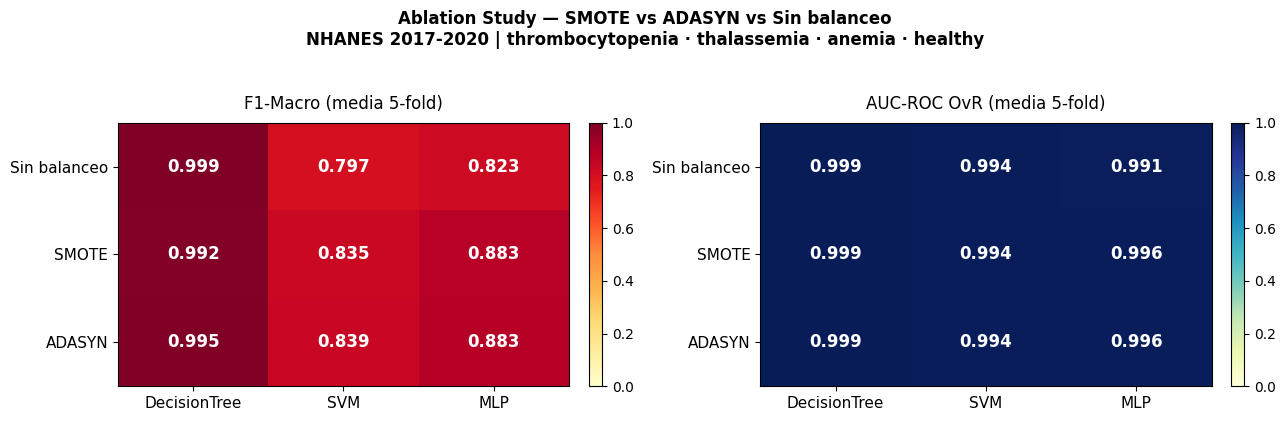

In [ ]:

# ─────────────────────────────────────────────────────────────────────────────
# 12. MAIN
# ─────────────────────────────────────────────────────────────────────────────
if __name__ == "__main__":


    X, y, class_names = load_and_prepare(data_NHANES_2017_2020)
    print(f"\n[Datos listos] X={X.shape}  |  Clases: {class_names}")

    print("\n[Ablation study — 5-fold CV estratificado]")
    results = run_ablation(X, y, class_names, n_splits=5)

    summary = build_summary(results)
    print("\n[Tabla resumen]")
    print(summary.to_string(index=False))

    results.to_csv("models_NHANES/ablation_raw_results.csv", index=False)
    summary.to_csv("models_NHANES/ablation_summary.csv",     index=False)
    print("\n[CSVs guardados] ablation_raw_results.csv | ablation_summary.csv")

    plot_results(results, "models_NHANES/ablation_results.png")